<a href="https://colab.research.google.com/github/safeai-snu/finance_ai_2025/blob/main/day4/TS_analysis_gold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## [HW-report (due: 250509)] 바뀐 dataset 으로 코드 전체 실행 후 파일 메일로 제출
- 제출: slcf.snu@gmail.com
- 이름_TS_analysis_btc.ipynb  파일
- data: https://github.com/safeai-snu/finance_ai_2025/blob/main/day4/btc.csv
- 필수 포함 사항: 맨 아래 Markdown (ARIMA 모델 적합 결과 해석 보고서) 수정 후 제출

In [ ]:
!pip install numpy==1.24.4
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
import itertools
import scipy.stats
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots  import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

# Data

### Data Load

In [ ]:
gold_url = 'https://raw.githubusercontent.com/SLCFLAB/DL-Forecasting/main/DL/day1/data/gold.csv'
silver_url = 'https://raw.githubusercontent.com/SLCFLAB/DL-Forecasting/main/DL/day1/data/silver.csv'
platinum_url = 'https://raw.githubusercontent.com/SLCFLAB/DL-Forecasting/main/DL/day1/data/platinum.csv'

gold = pd.read_csv(gold_url, index_col=0, parse_dates=['Date'])
silver = pd.read_csv(silver_url, index_col=0, parse_dates=['Date'])
platinum = pd.read_csv(platinum_url, index_col=0, parse_dates=['Date'])

### Data describe

In [ ]:
gold

,Date,Price
0,2017-01-03,1162.0
1,2017-01-04,1165.3
2,2017-01-05,1181.3
3,2017-01-06,1173.4
4,2017-01-09,1184.9
...,...,...
1285,2021-12-27,1808.8
1286,2021-12-28,1810.9
1287,2021-12-29,1805.8
1288,2021-12-30,1814.1


In [ ]:
price = gold.set_index(keys = 'Date')
diff = price.diff().dropna()

In [ ]:
price

,Price
Date,
2017-01-03,1162.0
2017-01-04,1165.3
2017-01-05,1181.3
2017-01-06,1173.4
2017-01-09,1184.9
...,...
2021-12-27,1808.8
2021-12-28,1810.9
2021-12-29,1805.8


In [ ]:
gold.isna().sum()

,0
Date,0
Price,0


In [ ]:
gold.describe()

,Date,Price
count,1290,1290.000000
mean,2019-07-03 08:34:36.279069696,1501.741550
min,2017-01-03 00:00:00,1162.000000
25%,2018-04-04 06:00:00,1278.525000
50%,2019-07-03 12:00:00,1411.600000
75%,2020-09-30 18:00:00,1774.575000
max,2021-12-31 00:00:00,2069.400000
std,NaN,254.202298


## 📉 금 가격 변화 시각화


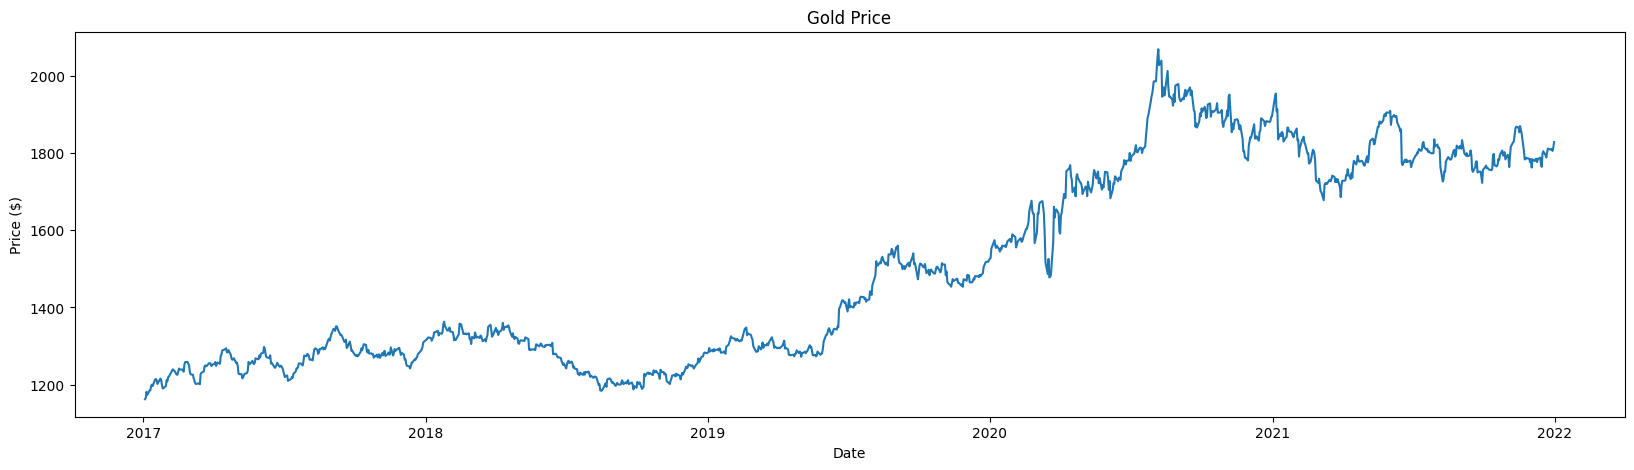

In [ ]:
fig, ax = plt.subplots(figsize = (20,5))

ax.plot(price)
ax.set_title('Gold Price')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
plt.show()

diff()로 구한 하루 전과의 가격 차이 시각화

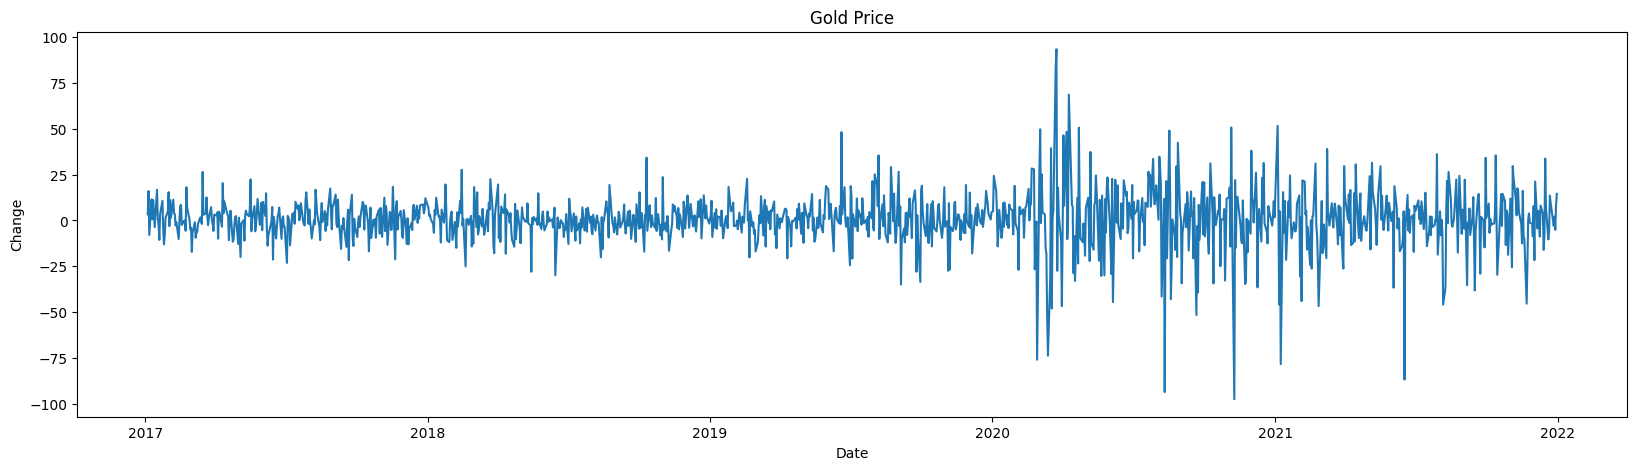

In [ ]:
fig, ax = plt.subplots(figsize = (20,5))

ax.plot(diff)
ax.set_title('Gold Price')
ax.set_xlabel('Date')
ax.set_ylabel('Change')

plt.show()

# Decomposition

### Box-Cox transformation
- Box-Cox 변환을 통해 **왜도(skewness)**를 줄이고, **정규성(normality)**을 개선할 수 있음
- x: 금 가격 데이터를 NumPy 배열로 변환
- stats.boxcox(): 데이터를 정규 분포에 가깝게 변형
- lambda_optimal: 최적의 λ 값을 찾아서 출력 (변환 강도 조절 매개변수)

In [ ]:
x = gold['Price'].to_numpy()
y, lambda_optimal = stats.boxcox(x)
print(lambda_optimal)

-1.6225791692441833


- 변환 전(x)과 변환 후(y) 데이터의 분포를 비교

<Axes: ylabel='Density'>

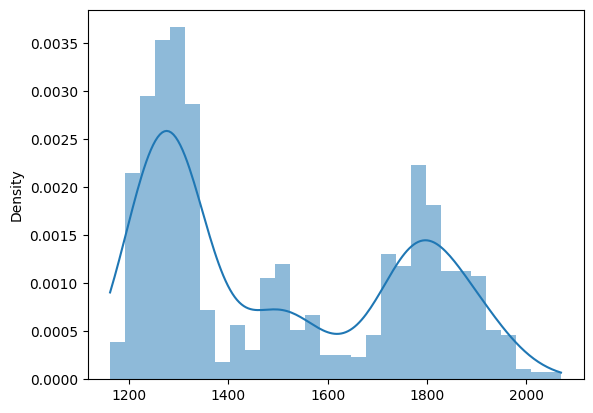

In [ ]:
sns.histplot(x, kde=True, bins=30, stat='density', linewidth=0)

<Axes: ylabel='Density'>

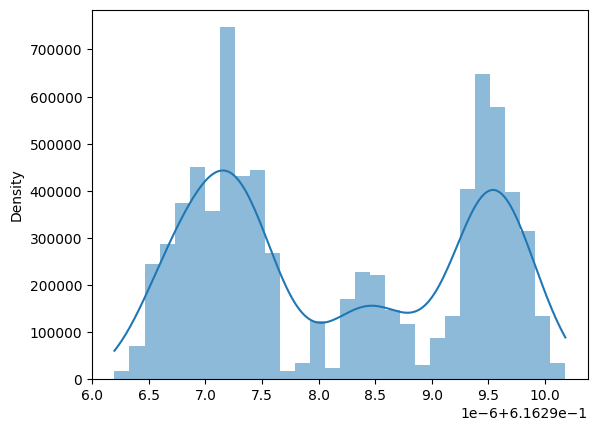

In [ ]:
sns.histplot(y, kde=True, bins=30, stat='density', linewidth=0)

### 금 가격의 5일 이동 평균 시각화
- rolling(window=5)을 사용해 5일 이동 평균을 계산하고 시각화합니다.
- center=True를 사용하면 중심값 기준으로 평균을 계산해 더 자연스러운 곡선을 얻을 수 있습니다.
- 원래 금 가격 데이터(Original Price)와 이동 평균(5-Day Moving Average)을 함께 시각화하여 변동 추세를 쉽게 확인할 수 있습니다.

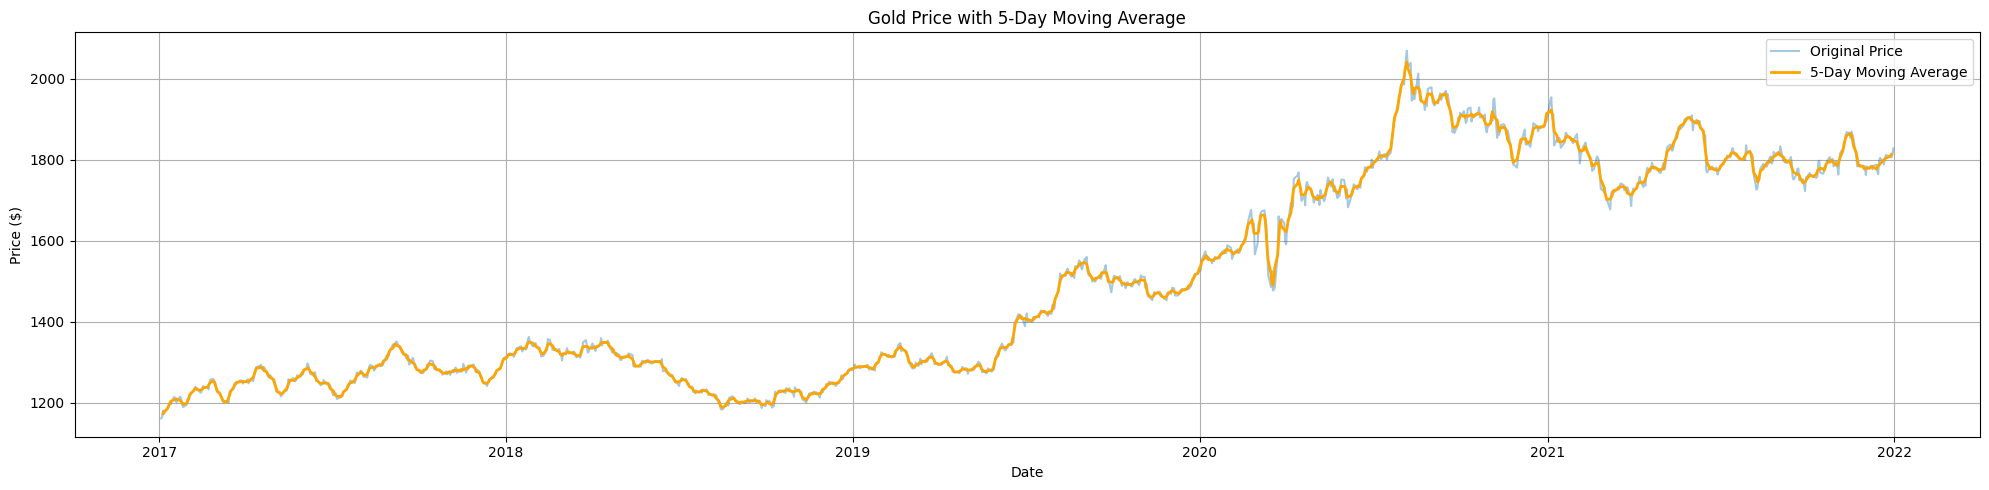

In [ ]:
# 5일 이동 평균 계산
gold['MA_5'] = gold['Price'].rolling(window=5, center=True).mean()

# 시각화
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(gold['Date'], gold['Price'], label='Original Price', alpha=0.4)
ax.plot(gold['Date'], gold['MA_5'], label='5-Day Moving Average', linewidth=2, color='orange')

# 그래프 설정
ax.set_title('Gold Price with 5-Day Moving Average')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

### 금 가격 시계열 분해 (Seasonal Decomposition)
0. seasonal_decompose()를 사용하여 시계열을 네 가지 성분으로 분해:
  - Observed: 실제 시계열
  - Trend: 장기적인 변화
  - Seasonal: 반복적인 계절성 패턴 (1년 ≈ 258 거래일 기준)
  - Residual: 위 세 요소를 제거한 나머지

1. Additive 모델
  - 시계열 = 추세 + 계절성 + 잔차
  - 성분 간 크기가 독립적일 때 적합

2. Multiplicative 모델
  - 시계열 = 추세 × 계절성 × 잔차
  - 성분이 비례 관계일 때 적합

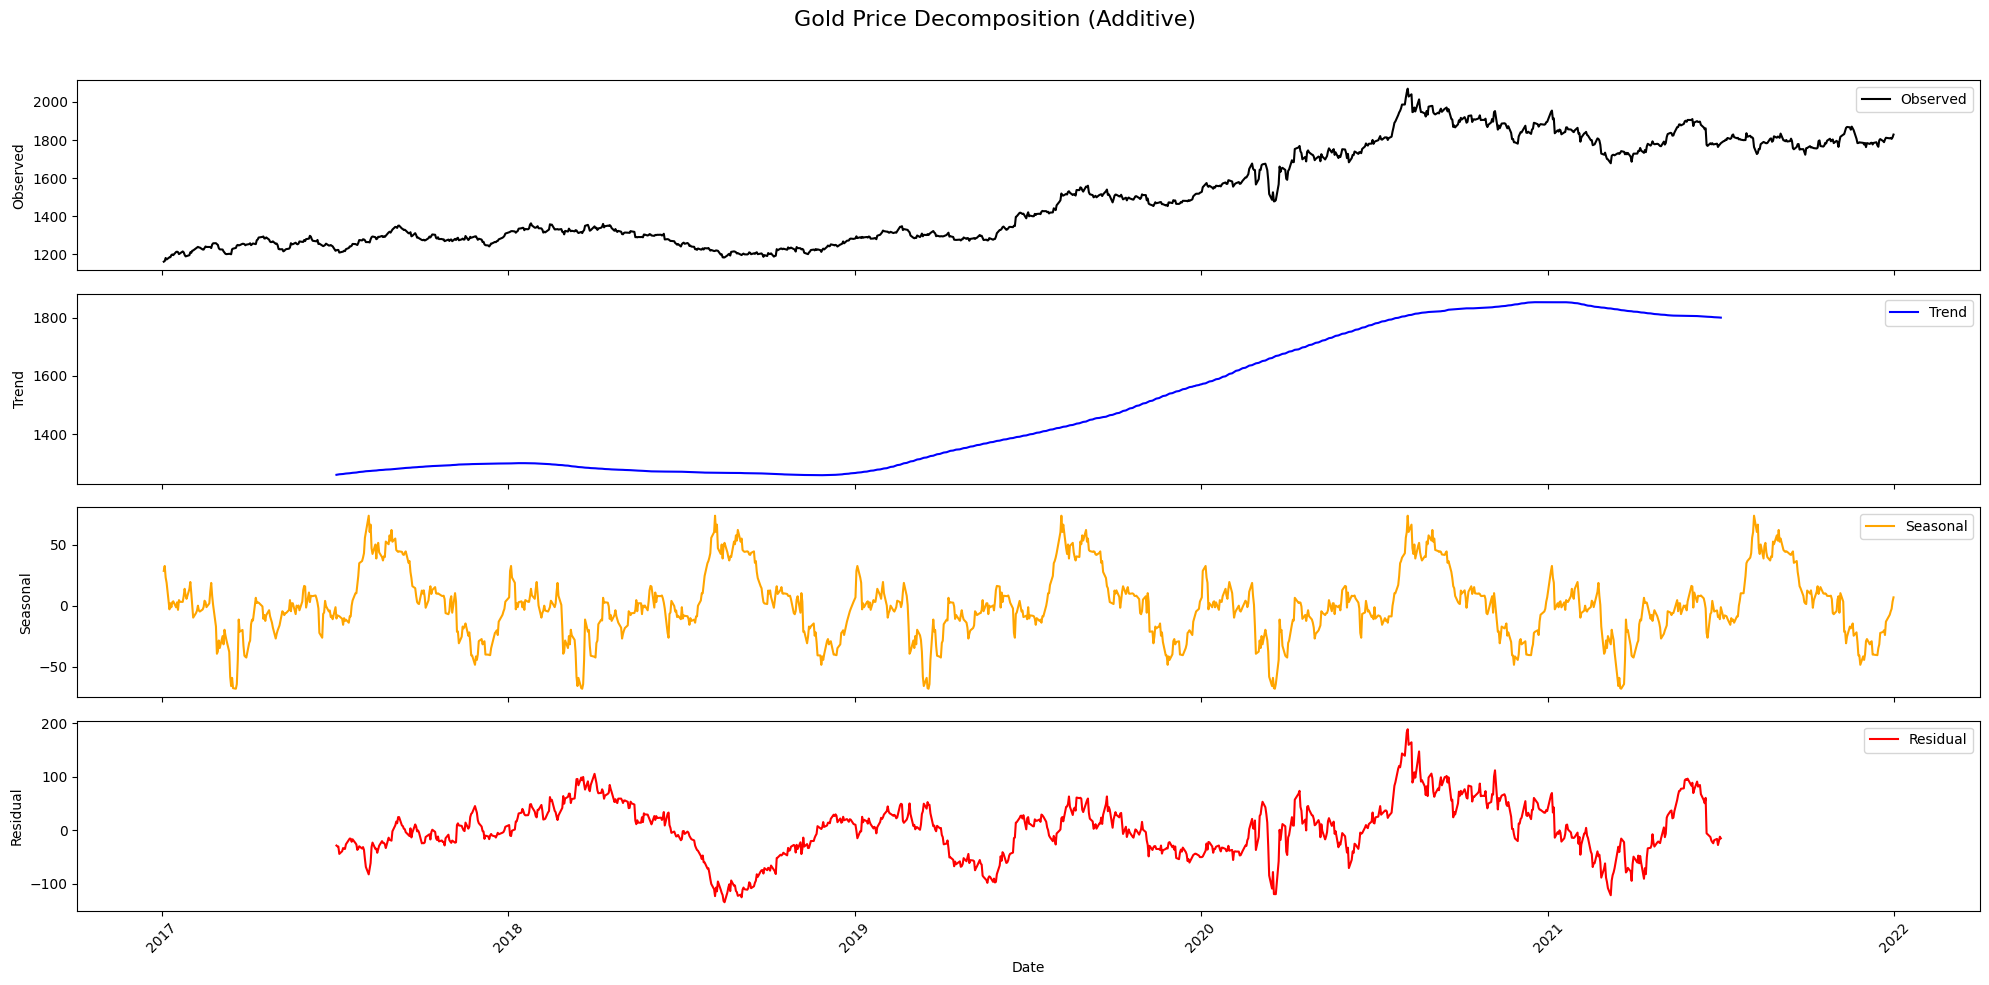

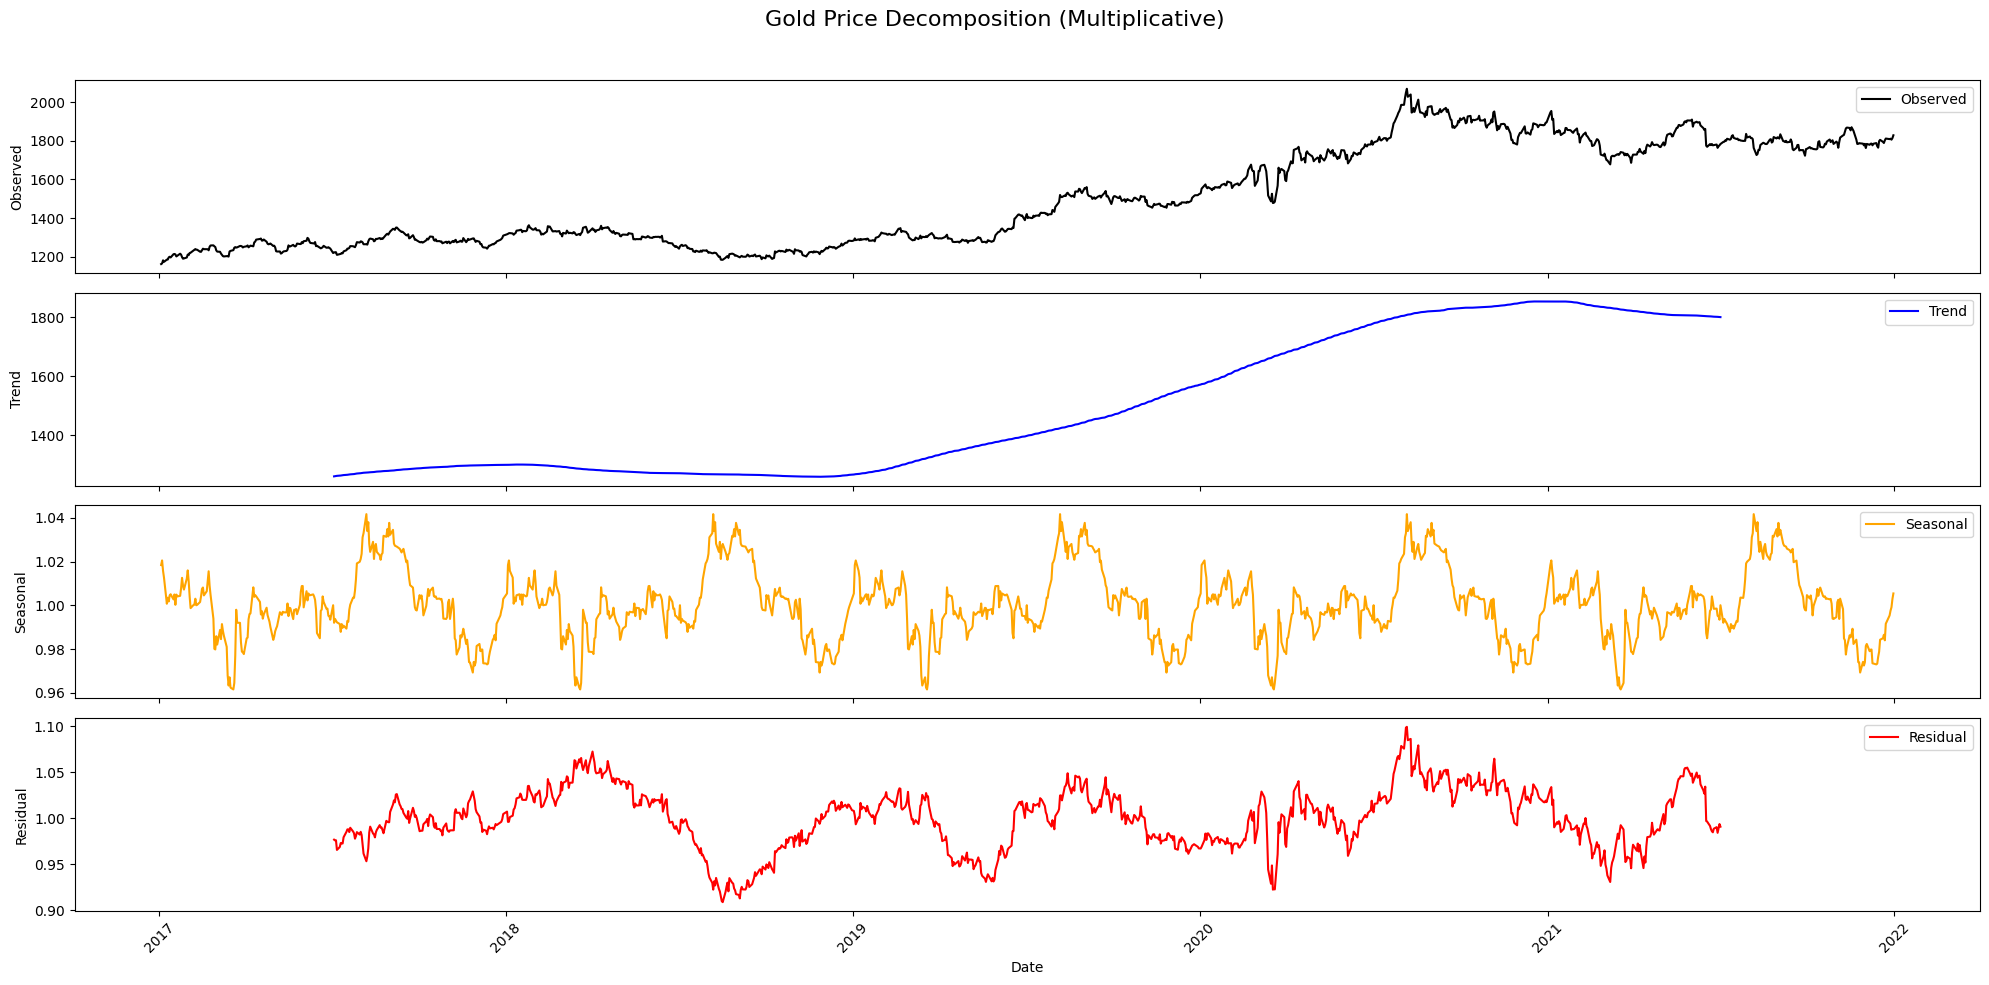

In [ ]:
# 분해
decomp_add = seasonal_decompose(price, model='additive', period=258)
decomp_mul = seasonal_decompose(price, model='multiplicative', period=258)

def plot_decomposition(decomp, title):
    fig, axs = plt.subplots(4, 1, figsize=(20, 10), sharex=True)
    fig.suptitle(title, fontsize=16)

    axs[0].plot(decomp.observed, label='Observed', color='black')
    axs[0].set_ylabel('Observed')
    axs[0].legend()

    axs[1].plot(decomp.trend, label='Trend', color='blue')
    axs[1].set_ylabel('Trend')
    axs[1].legend()

    axs[2].plot(decomp.seasonal, label='Seasonal', color='orange')
    axs[2].set_ylabel('Seasonal')
    axs[2].legend()

    axs[3].plot(decomp.resid, label='Residual', color='red')
    axs[3].set_ylabel('Residual')
    axs[3].legend()

    axs[3].set_xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# 시각화
plot_decomposition(decomp_add, 'Gold Price Decomposition (Additive)')
plot_decomposition(decomp_mul, 'Gold Price Decomposition (Multiplicative)')

# Stationarity

## Unit root test
- Augmented Dickey-Fuller (ADF) 검정은 단위근 (unit root) 검정 방법으로, 시계열 데이터가 **정상성 (stationarity)**을 갖는지 여부를 판단하는 통계적 테스트입니다. 정상성은 시계열 데이터가 시간이 지나도 평균과 분산이 일정하게 유지되는 특성을 의미합니다.
- 단위근은 시계열 데이터의 특정한 특성으로, 비정상적인 시계열에서 나타납니다. 즉, 단위근을 가진 시계열은 정상성이 없으며, 이는 시간에 따라 예측 불가능하게 변동할 수 있음을 의미합니다.
- ADF 검정 절차
  - H0: 시계열에 단위근이 존재한다 (non-stationarity).
  - H1: 시계열에 단위근이 존재하지 않는다 (stationarity).

In [ ]:
def ADF(data):
    result = adfuller(data, autolag='AIC')  # ADF 검정 실행

    print('----- ADF Test -----')
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.10f}")
    print(f"Lag: {result[2]}")
    print(f"Number of Observations: {result[3]}")

    print('Critical Values:')
    for key, value in result[4].items():
        print(f"\t{key}: {value:.3f}")

    # Test conclusion
    if result[1] <= 0.05:
        print("The series is likely stationary (Reject H0).")
    else:
        print("The series is likely non-stationary (Fail to reject H0).")

In [ ]:
# ADF 테스트 결과 출력
print("Results for Price Data:")
ADF(price['Price'])

print("\nResults for Differenced Data:")
ADF(diff['Price'])

Results for Price Data:
----- ADF Test -----
ADF Statistic: -0.806442
p-value: 0.8172225725
Lag: 6
Number of Observations: 1283
Critical Values:
	1%: -3.435
	5%: -2.864
	10%: -2.568
The series is likely non-stationary (Fail to reject H0).

Results for Differenced Data:
----- ADF Test -----
ADF Statistic: -17.368823
p-value: 0.0000000000
Lag: 5
Number of Observations: 1283
Critical Values:
	1%: -3.435
	5%: -2.864
	10%: -2.568
The series is likely stationary (Reject H0).


## ACF / PACF

1. ACF (Autocorrelation Function)
  - ACF는 시계열 데이터의 **시간 지연(lag)**에 따른 상관 관계를 측정합니다.
  - ACF는 전체 상관 관계를 고려하여, 각 시점 간의 연관성을 보여줍니다.
  - 예: lag=1일 때 오늘과 어제의 값이 얼마나 관련 있는지를 나타냅니다.

2. PACF (Partial Autocorrelation Function)
  - PACF는 부분 자기상관을 측정하며, 이전 지연들의 영향을 제거한 후 순수한 상관 관계를 보여줍니다.
  - PACF는 AR(자기회귀) 모델에서 중요한 역할을 하며, 적절한 지연(lag)수를 선택하는 데 유용합니다.

3. ACF와 PACF의 차이점
  - ACF는 시계열 데이터의 전체 상관 관계를 보여주고, PACF는 순수한 상관 관계만을 보여줍니다.
  - ACF는 주기성이나 추세를 찾는 데, PACF는 AR 모델의 차수를 결정하는 데 유용합니다.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def acf_plot(data, lags):
    plt.figure(figsize=(10, 6))
    plot_acf(data, lags=lags, ax=plt.gca())
    plt.title('Autocorrelation Function (ACF)')
    plt.xlabel('Lags')
    plt.ylabel('Autocorrelation')
    plt.show()

def pacf_plot(data, lags):
    plt.figure(figsize=(10, 6))
    plot_pacf(data, lags=lags, ax=plt.gca())
    plt.title('Partial Autocorrelation Function (PACF)')
    plt.xlabel('Lags')
    plt.ylabel('Partial Autocorrelation')
    plt.show()

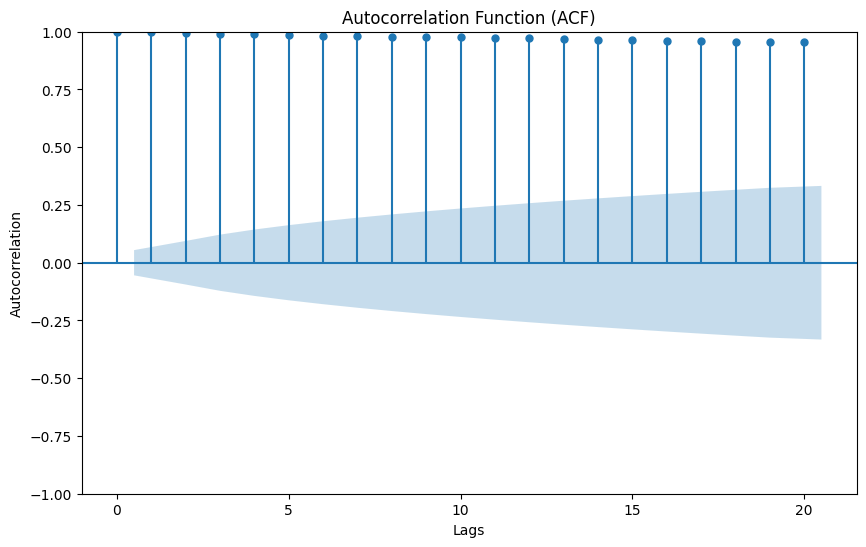

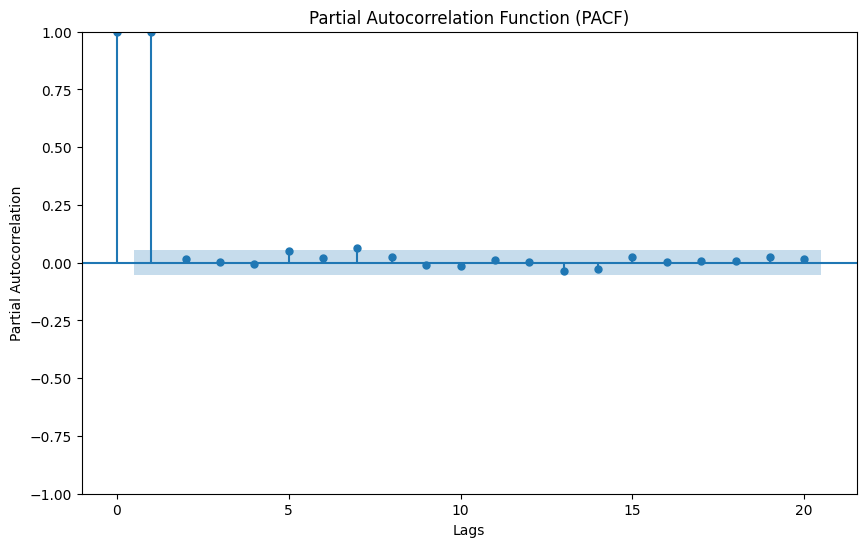

In [ ]:
acf_plot(price, 20)
pacf_plot(price, 20)

- 차분 전 price 데이터에서는 긴 자기상관이 보이며, 정상성을 만족하지 않아서 추세나 패턴이 남아 있습니다. ACF가 천천히 감소하고, PACF에서는 몇 개의 지연에서 강한 상관을 나타낼 수 있습니다.

- 차분 후 diff 데이터에서는 ACF와 PACF가 급격히 0으로 수렴하여 정상성을 만족합니다. 이는 차분 후, 데이터가 더 이상 추세나 패턴을 포함하지 않음을 의미하며, 모델링에 적합한 상태가 됩니다.

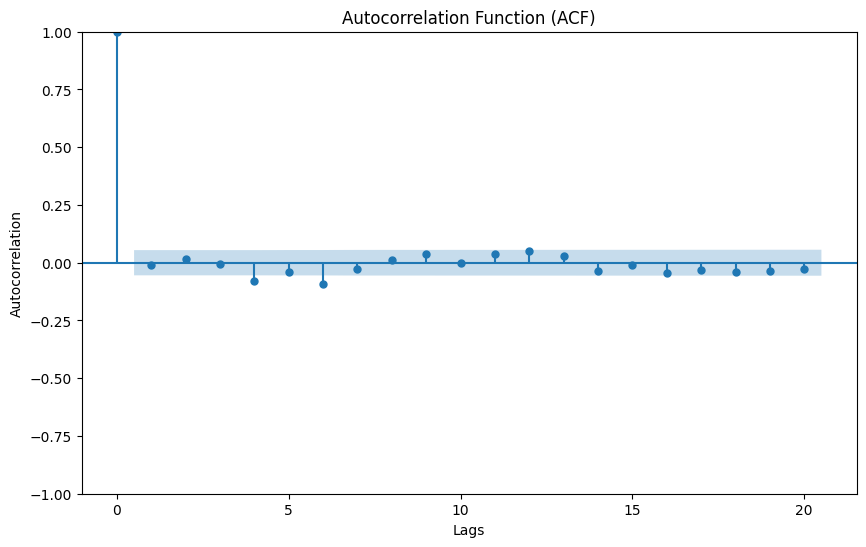

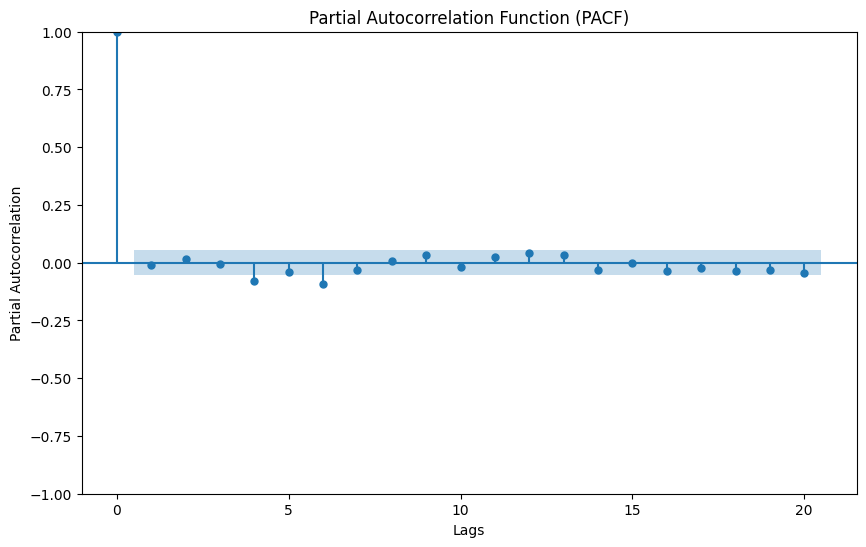

In [ ]:
acf_plot(diff, 20)
pacf_plot(diff, 20)

# ARIMA

- 데이터 분할: 전체 데이터에서 20%는 테스트용, 나머지 80%는 훈련용 데이터로 나눕니다.
- 자동 모델 선택 (auto_arima): auto_arima를 사용해 최적의 ARIMA 모델을 선택합니다. 이때 AIC와 BIC를 기준으로 모델을 선택합니다.
- 모델 비교: 자동으로 선택된 모델과 함께, ARIMA 모델의 다양한 파라미터 (p, d, q) 조합을 수동으로 탐색하여 각 모델의 성능(AIC, BIC)을 비교합니다.

## Train-Test split

In [ ]:
forecasting_horizon = int(gold.shape[0]*0.2)
train = price[:-forecasting_horizon]
test = price[-forecasting_horizon:]

## ARIMA 모델 성능 및 잔차 진단 지표 설명

- AIC (Akaike Information Criterion)
  - 모델의 **적합도 + 복잡도**를 고려하는 지표
  - **작을수록** 더 좋은 모델
  - Overfitting 방지에 도움

- BIC (Bayesian Information Criterion)
  - AIC와 유사하지만 **모델 단순성**을 더 강하게 선호
  - 역시 **작을수록** 좋은 모델
  - 샘플 수가 많을수록 복잡한 모델에 더 불리함

- Ljung-Box 검정
  - 잔차에 **자기상관이 남아있는지** 검정
  - `p-value > 0.05`: 잔차가 무작위성 만족 → 적절한 모델
  - `p-value < 0.05`: 잔차에 패턴 존재 → 모델 개선 필요

- Jarque-Bera 정규성 검정
  - 잔차가 **정규분포를 따르는지** 확인
  - `p-value > 0.05`: 정규성 만족
  - `p-value < 0.05`: 정규성 위배 → 이상치나 왜도 가능성

- Heteroskedasticity (이분산성)
  - 잔차의 **분산이 일정한가**를 검정
  - 이분산성 존재 시 → 예측 신뢰구간 왜곡 가능
  - 해결 방법: GARCH 모델 등 고려

- Skewness (왜도)
  - 분포의 **비대칭성**을 나타냄
  - 0: 대칭,  
    < 0: 왼쪽 치우침,  
    > 0: 오른쪽 치우침
  - 예: `-0.40` → 왼쪽 치우친 분포

- Kurtosis (첨도)
  - 분포의 **뾰족함 또는 평평함** 정도
  - 3: 정규분포,  
    > 3: 뾰족한 분포 (leptokurtic),  
    < 3: 평평한 분포 (platykurtic)
  - 예: `11.71` → 매우 뾰족함, 이상치 가능성 ↑


## Fitting

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Use auto_arima to find best ARIMA order
model_aic = auto_arima(train, seasonal=False, trace=True, information_criteria='aic')
model_bic = auto_arima(train, seasonal=False, trace=True, information_criteria='bic')

# Print summaries of the best models based on AIC and BIC
print("Best model by AIC:")
print(model_aic.summary())

print("Best model by BIC:")
print(model_bic.summary())

# Alternatively, if you still want to use the manual ARIMA grid search:
orders = list(itertools.product(range(0, 6), range(0, 3), range(0, 6)))
dict_model = {}

# Loop over possible combinations of (p,d,q)
for order in orders:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        dict_model[order] = [model_fit.llf, model_fit.aic, model_fit.bic]
    except Exception as e:
        print(f"Error for order {order}: {e}")
        continue

# Convert the results into a DataFrame for easy comparison
information = pd.DataFrame.from_dict(dict_model, orient='index', columns=['llf', 'Aic', 'Bic'])

# Display results by BIC and AIC
print("By BIC:")
print(information.sort_values(by=['Bic'], ascending=True))

print("By AIC:")
print(information.sort_values(by=['Aic'], ascending=True))

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=8372.750, Time=7.00 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8374.989, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8376.861, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8376.869, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8375.636, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=8376.308, Time=4.38 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=8379.592, Time=1.76 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=8374.706, Time=6.11 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=8354.616, Time=8.00 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=8372.701, Time=3.33 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=8356.610, Time=7.80 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=8356.606, Time=1.59 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=8367.104, Time=0.93 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=8357.151, Time=2.38 sec
 ARIMA(2,1,3)(0,0,0)[0]          

## ARIMA 모델 적합 결과 해석 보고서
### Example (형식은 자유)

위 실습에서는 금 가격 데이터에 대한 예측력을 극대화하기 위해 pmdarima 라이브러리의 auto_arima 함수를 활용하여 AIC(Akaike Information Criterion) 및 BIC(Bayesian Information Criterion)를 최소화하는 ARIMA 모델을 탐색하였다. Stepwise 방식의 탐색 결과, 두 정보 기준 모두에서 최적 모델로 ARIMA(2, 1, 3) 모델이 선정되었다.

모델 coefficient 분석 결과, 대부분의 자기회귀(AR) 및 이동평균(MA) 계수는 통계적으로 유의미한 수준에서 0이 아니며(p < 0.001), 이는 시계열 데이터가 AR 및 MA 구성요소의 영향을 받음을 시사한다. 상수항(intercept)은 유의수준 0.05에서 통계적으로 유의하지 않으며, 이는 차분(d=1)된 시계열이 평균 0 주위에서 진동하고 있음을 암시한다.

또한 아래와 같은 분석 결과를 얻었다. 전반적으로 모델은 잔차의 자기상관은 잘 제거했지만, 잔차의 정규성과 등분산성 가정은 위배될 수 있다.
- Ljung-Box 검정 (Lag=1): p-value = 0.99 → 잔차에 자기상관이 없다고 판단할 수 있음.
- Jarque-Bera 정규성 검정: JB 통계량 = 3283.89, p-value ≈ 0.00 → 잔차는 정규성을 따르지 않음.
- Heteroskedasticity (ARCH 효과): p-value ≈ 0.00 → 분산 불균등성 존재 가능성 있음.
- 왜도 (Skewness) = -0.40, 첨도 (Kurtosis) = 11.71 → 잔차 분포는 왼쪽으로 치우쳐 있으며, 정규분포보다 뾰족한 형태를 가짐 (leptokurtic).

마지막으로 본 모델을 바탕으로 한 시계열 적합 결과 및 향후 예측에 대한 시각화를 진행하였다.


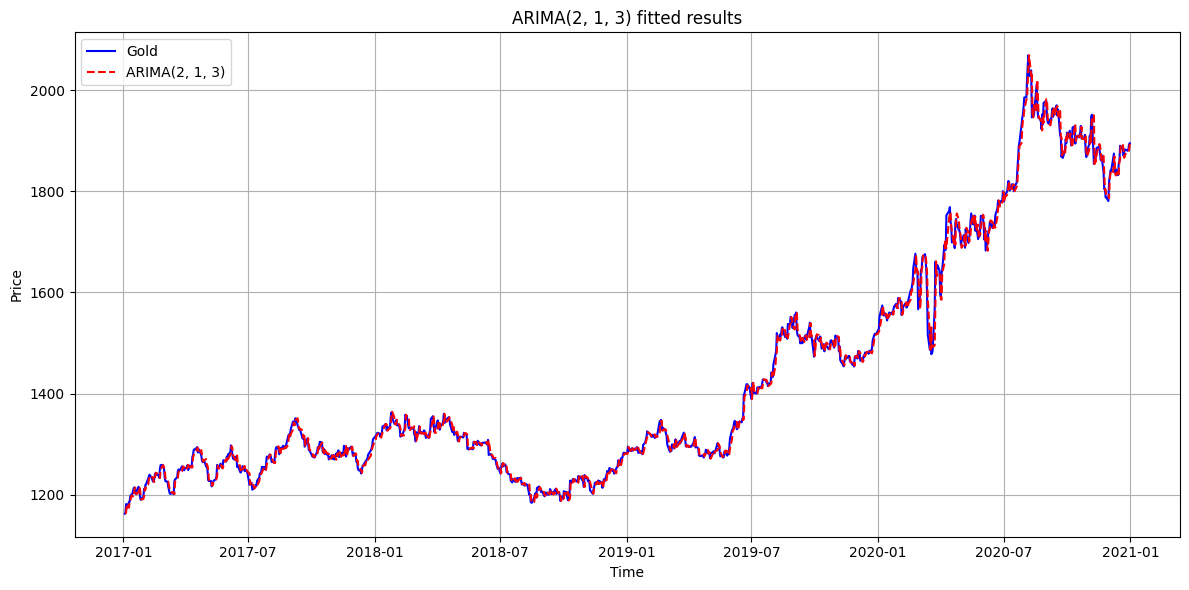

In [ ]:
import matplotlib.pyplot as plt

# AIC 기준 최적 모델로부터 예측값 가져오기
model = ARIMA(train, order=model_aic.order)
model_fit = model.fit()

# 훈련 구간에 대한 예측값
fitted_values = model_fit.fittedvalues

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(train, label='Gold', color='blue')
plt.plot(fitted_values[1:], label=f'ARIMA{model_aic.order}', color='red', linestyle='--')
plt.title(f'ARIMA{model_aic.order} fitted results')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()
